different method

In [254]:
import numpy as np 
import matplotlib.pyplot as plt
import math

In [255]:
#find the intersection points, if they do not intersect returns None
#a tangent line should not count at intersecting the circle for this
def FindIntersectionPoints_of_CircleAndLine(point, angle, circle_center, r):
    x0, y0 = point 
    h, k = circle_center

    #for vertical line
    if np.abs(angle) == np.pi/2:
        d=r**2-(x0-h)**2
        #check if value is real, if it is not, they don't intersect
        if d>0:
            x1 = x0
            y1 = (d)**(0.5)+k
            
            x2 = x0
            y2 = -(d)**(0.5)+k 
            return (x1,y1), (x2,y2)
        else: 
            return None, None
    else:
        
        m = np.tan(angle)
        d=(m * (y0 - m*x0 - k) - h)**2 - (1 + m**2)*(h**2 + (y0 - m*x0 - k)**2 - r**2)
        #check if value is real, if it is not, they don't intersect
        if d>0:
            x_plus = (h - m * (y0 - m*x0 - k) + math.sqrt(d)) / (1 + m**2)
            y_plus = m*(x_plus-x0)+y0
            
            x_minus = (h - m * (y0 - m*x0 - k) - math.sqrt(d)) / (1 + m**2)
            y_minus = m*(x_minus-x0)+y0

            return (x_minus,y_minus), (x_plus,y_plus)

        else: 
            return None, None
            
#assumes travel is limited to positive x direction
#if any of x1,x2, or xs are equal or very close this will return None
def nextIntersectionPoint(ps, p1, p2):
    xs, ys = ps
    x1, y1 = p1
    x2, y2 = p2

    # For floating point errors, if xs is extremely close to x1
    epsilon = 0.00001

    # Only consider points that are physically ahead of the current position
    x1_is_ahead = x1 > (xs + epsilon)
    x2_is_ahead = x2 > (xs + epsilon)

    if x1_is_ahead and x2_is_ahead: 
        if x1 < x2:
            return p1 
        else: 
            return p2
    elif x1_is_ahead:
        return p1
    elif x2_is_ahead:
        return p2
    else: 
        return None
    

In [256]:
#global variables
objects = []   # stores all objects  

#clears all objects
def clearObjects():
    global objects
    objects = []

class backgroundMedium:
    def __init__(self, n):
        self.refractiveIndex=n
        #make sure that background Medium is first object
        objects.insert(0,self)

#circle is a subclass of polygon
class Circle():
    def __init__(self, xc, yc, r, n, color,points=1000):
        self.xCenter = xc
        self.yCenter = yc
        self.radius=r
        self.points=points
        eachPoint=int(points/2)
        
        self.x = np.array(np.linspace(self.xCenter-r, self.xCenter+r, num=eachPoint))
        self.yPositive = (r**2-(self.x-self.xCenter)**2)**(0.5) + self.yCenter
        self.yNegative = -1*(r**2-(self.x-self.xCenter)**2)**(0.5) + self.yCenter

        self.allX = np.concatenate([self.x, self.x[::-1]])
        self.allY = np.concatenate([self.yPositive, self.yNegative[::-1]])

        self.refractiveIndex = n
        self.color=color
        objects.append(self)

In [257]:
class Ray: 
    def __init__(self, y_pos, x_pos=0, theta=0):
        self.ypos = y_pos
        self.xpos = x_pos
        #why must math module do everything in radians????
        self.angle = math.radians(theta)
        
        #starts in background
        self.currentObjectIndex=0
        self.bigList = []
        self.bigList.append((self.xpos, self.ypos,self.angle,self.currentObjectIndex))
        #important
        objects.append(self)
        
    def find_andGoTo_NextIntersection_Point(self):
        NextIntersection_Point = None
        NextInsersectionObjectIndex = None
        for i in range(len(objects)): 
            obj = objects[i]
            if isinstance(obj,Circle):
                p1, p2 = FindIntersectionPoints_of_CircleAndLine(point = (self.xpos,self.ypos), 
                                                                 angle = self.angle, 
                                                                 circle_center = (obj.xCenter, obj.yCenter), 
                                                                 r=obj.radius)
                if p1 is None or p2 is None: 
                    pass 
                else: 
                    p = nextIntersectionPoint((self.xpos,self.ypos), p1, p2)
                    if p == None: 
                        pass 
                    else: 
                        if NextIntersection_Point is None:
                            NextIntersection_Point = p
                            NextInsersectionObjectIndex = i
                        else:
                            xn, yn = NextIntersection_Point
                            xp, yp = p
                            if xp < xn:
                                NextIntersection_Point = p
                                NextInsersectionObjectIndex = i 
            
        if NextIntersection_Point is not None: 
            xn, yn = NextIntersection_Point
            h = objects[NextInsersectionObjectIndex].xCenter
            k = objects[NextInsersectionObjectIndex].yCenter
            previousObjectIndex=self.currentObjectIndex
            
            #if we are on the same object, this means that this point is the exit point
            if NextInsersectionObjectIndex==previousObjectIndex:
                #revert to the background medium
                NextInsersectionObjectIndex=0
            #On different Object, must have been travelling through air
            else:
                previousObjectIndex=0
            #vertical line
            if (xn-h)==0: 
                theta_t=math.pi/2
            else: 
                #normal of circle, found from derivative
                theta_t = math.atan((yn-k)/(xn-h))
            previousObject = objects[previousObjectIndex]
            NextInsersectionObject = objects[NextInsersectionObjectIndex]
            
            #Snell's Law!
            n1=previousObject.refractiveIndex
            n2=NextInsersectionObject.refractiveIndex
            theta1=self.angle
            theta2 = math.asin((n1/n2)*math.sin(theta1-theta_t))+theta_t
                
            #save everything
            self.angle = theta2
            self.xpos = xn
            self.ypos = yn
            
            # FIX: Nudge the ray slightly forward along its new path 
            # This physically pushes it past the boundary line it just hit
            epsilon = 0.0001
            self.xpos += epsilon * math.cos(self.angle)
            self.ypos += epsilon * math.sin(self.angle)
            
            self.currentObjectIndex = NextInsersectionObjectIndex
            self.bigList.append((self.xpos, self.ypos,self.angle,self.currentObjectIndex))
            return (xn,yn, theta2)
        else: 
            return None
        
    def Go(self, anotherStep=0):
        state = self.find_andGoTo_NextIntersection_Point()
        while state is not None:
            state = self.find_andGoTo_NextIntersection_Point()
        self.xpos=self.xpos+anotherStep*np.cos(self.angle)
        self.ypos=self.ypos+anotherStep*np.sin(self.angle)
        self.bigList.append((self.xpos, self.ypos,self.angle,self.currentObjectIndex))

#move all ray objects 
def move_allRays(anotherStep=0):
    global objects
    for obj in objects:
        if isinstance(obj,Ray):
            obj.Go(anotherStep=anotherStep)

In [258]:
def plotEverything(objects, title, xlim=None,ylim=None,color='r',linewidth=1):
    plt.figure() 
    
    for obj in objects:
        if isinstance(obj, Circle):
            plt.fill(obj.allX, obj.allY, color=obj.color, alpha=0.4)
        if isinstance(obj, Ray):
            # print(obj.bigList)
            x,y,angle,objects = zip(*obj.bigList)
            print(objects)
            print(angle)
            plt.plot(x,y,color=color, linewidth=linewidth, marker='o',markersize='5')

            
    if xlim is not None: 
        plt.xlim(xlim)
    if ylim is not None:
        plt.ylim(ylim)
    
    if xlim is None and ylim is None:
        plt.axis("equal")
    plt.title(title)
    plt.show

(0, 8, 0, 9, 0, 0)
(0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
(0, 8, 0, 9, 0, 0)
(0.0, -0.08523217592238935, -0.17046435184477868, -0.09409241552575615, -0.017720479206733503, -0.017720479206733503)
(0, 8, 0, 9, 0, 0)
(0.0, 0.08523217592238935, 0.17046435184477868, 0.09409241552575615, 0.017720479206733503, 0.017720479206733503)
(0, 8, 0, 9, 0, 0)
(0.0, -0.18376186614417694, -0.3675237322883538, -0.18104036902644324, 0.005442994235467347, 0.005442994235467347)
(0, 8, 0, 9, 0, 0)
(0.0, 0.18376186614417694, 0.3675237322883538, 0.18104036902644324, -0.005442994235467347, -0.005442994235467347)
(0, 8, 0, 9, 0, 0)
(0.0, -0.3244633033831822, -0.6489266067663646, -0.09909395175459301, 0.4507387032571831, 0.4507387032571831)
(0, 8, 0, 9, 0, 0)
(0.0, 0.3244633033831822, 0.6489266067663646, 0.09909395175459301, -0.4507387032571831, -0.4507387032571831)


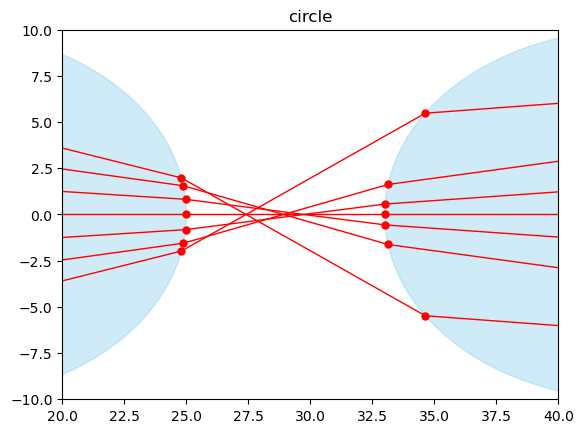

In [276]:
clearObjects()   #resets, clears the "board"
backgroundMedium(n=1)

ray4 = Ray(y_pos=0, theta=0, x_pos=0)

ray3 = Ray(y_pos=2.5, theta=0, x_pos=0)
ray5 = Ray(y_pos=-2.5, theta=0, x_pos=0)

ray2 = Ray(y_pos=5, theta=0, x_pos=0)
ray6 = Ray(y_pos=-5, theta=0, x_pos=0)

ray1 = Ray(y_pos=7.5, theta=0, x_pos=0)
ray7 = Ray(y_pos=-7.5, theta=0, x_pos=0)


circle1 = Circle(xc=15, yc=0, r=10, n=1.5, color='skyblue')

circle2 = Circle(xc=43, yc=0, r=10, n=1.5, color='skyblue')

move_allRays(anotherStep=3)
plotEverything(objects,title='circle',ylim=(-10,10),xlim=(20,40))